In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.datasets import fetch_california_housing
# -----------------------------
# 1. Load MNIST
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use subset for speed
train_subset = torch.utils.data.Subset(train_dataset, range(5000))
test_subset  = torch.utils.data.Subset(test_dataset, range(1000))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=5000, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_subset, batch_size=1000, shuffle=False)

train_data, train_labels = next(iter(train_loader))
test_data, test_labels   = next(iter(test_loader))



5000 1000


In [ ]:

def knn_predict(train_x, train_y, test_x, k):
    # Compute distance: (test - train)^2
    dists = torch.cdist(test_x, train_x)  # [num_test, num_train]

    # Get k nearest
    knn_idx = dists.topk(k, largest=False).indices  # smallest distances
    knn_labels = train_y[knn_idx]  # [num_test, k]

    # Majority vote
    preds = []
    for labels in knn_labels:
        vals, counts = labels.unique(return_counts=True)
        preds.append(vals[counts.argmax()])
    
    return torch.stack(preds)

# print(len(train_data), len(test_data))
def knn_predict_regression(train_x, train_y, test_x, k):
    dists = torch.cdist(test_x, train_x)  # [num_test, num_train]

    knn_idx = dists.topk(k, largest=False).indices  # nearest neighbors
    knn_values = train_y[knn_idx]  # [num_test, k]

    # Regression: take mean
    preds = knn_values.mean(dim=1)
    
    return preds


In [ ]:
import matplotlib.pyplot as plt

ks = list(results.keys())
mses = [results[k]["mse"] for k in ks]
r2s = [results[k]["r2"] for k in ks]

# MSE Plot
plt.figure()
plt.plot(ks, mses)
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("KNN: MSE vs k")
plt.show()

# R2 Plot
plt.figure()
plt.plot(ks, r2s)
plt.xlabel("k")
plt.ylabel("R^2")
plt.title("KNN: R^2 vs k")
plt.show()

In [ ]:
results = {}

for k in range(1, 30):
    preds = knn_predict_regression(train_data, train_labels.float(), test_data, k)

    # MSE
    mse = ((preds - test_labels.float()) ** 2).mean().item()

    # R^2
    mean_y = test_labels.float().mean()
    ss_total = ((test_labels.float() - mean_y) ** 2).sum()
    ss_res = ((test_labels.float() - preds) ** 2).sum()
    r2 = 1 - (ss_res / ss_total)

    results[k] = {"mse": mse, "r2": r2.item()}

    print(f"k={k:2d} | MSE={mse:.4f} | R2={r2:.4f}")

In [ ]:
results = {}

for k in range(1, 30):
    preds = knn_predict(train_data, train_labels, test_data, k)
    acc = (preds == test_labels).float().mean().item()
    results[k] = acc
    print(f"k = {k:2d} | Accuracy = {acc:.4f}")


print("\nSummary:")
for k, acc in results.items():
    print(f"k={k}: {acc:.4f}")

k =  1 | Accuracy = 0.9020
k =  2 | Accuracy = 0.8950
k =  3 | Accuracy = 0.9090
k =  4 | Accuracy = 0.9080
k =  5 | Accuracy = 0.9100
k =  6 | Accuracy = 0.9040
k =  7 | Accuracy = 0.9070
k =  8 | Accuracy = 0.9100
k =  9 | Accuracy = 0.9050
k = 10 | Accuracy = 0.8980
k = 11 | Accuracy = 0.8910
k = 12 | Accuracy = 0.8930
k = 13 | Accuracy = 0.8910
k = 14 | Accuracy = 0.8900
k = 15 | Accuracy = 0.8910
k = 16 | Accuracy = 0.8910
k = 17 | Accuracy = 0.8890
k = 18 | Accuracy = 0.8830
k = 19 | Accuracy = 0.8840
k = 20 | Accuracy = 0.8810
k = 21 | Accuracy = 0.8800
k = 22 | Accuracy = 0.8740
k = 23 | Accuracy = 0.8760
k = 24 | Accuracy = 0.8730
k = 25 | Accuracy = 0.8730
k = 26 | Accuracy = 0.8700
k = 27 | Accuracy = 0.8690
k = 28 | Accuracy = 0.8710
k = 29 | Accuracy = 0.8710

Summary:
k=1: 0.9020
k=2: 0.8950
k=3: 0.9090
k=4: 0.9080
k=5: 0.9100
k=6: 0.9040
k=7: 0.9070
k=8: 0.9100
k=9: 0.9050
k=10: 0.8980
k=11: 0.8910
k=12: 0.8930
k=13: 0.8910
k=14: 0.8900
k=15: 0.8910
k=16: 0.8910
k=17: 0.

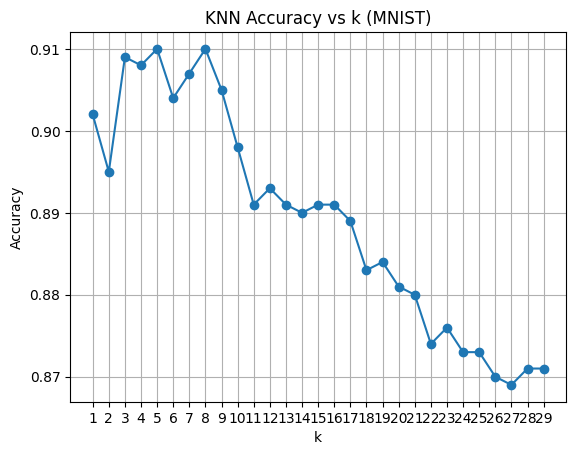

In [7]:
import matplotlib.pyplot as plt

ks = list(results.keys())
accs = list(results.values())

plt.figure()
plt.plot(ks, accs, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k (MNIST)")
plt.xticks(ks)
plt.grid()

plt.show()